In [1]:
import os
import sys

os.environ["XDG_SESSION_TYPE"] = "x11"
os.environ["OPEN3D_DISABLE_WEB_VISUALIZER"] = "true"     

import numpy as np
import matplotlib.pyplot as plt

sys.path.append('../src')
from models import canonical_model_name, get_most_epochs_file, MODEL_SHORTHANDS
from stats import load_training_stats

In [2]:
from consts import OUTPUT_DIR

STATS_DIR = OUTPUT_DIR / "stats"

In [11]:
EDGE_ENCODER = "all_minilm_l6v2"
NODE_ENCODER = "all_minilm_l6v2"
QUERY_ENCODER = "all_minilm_l6v2"
MULTI_ANSWER = True
MULTI_ANSWER_ARG = str(MULTI_ANSWER).lower()


def get_model_name(model_name):
    if model_name in MODEL_SHORTHANDS:
        model_name = canonical_model_name(
            MODEL_SHORTHANDS[model_name].format(
                edge_encoder=EDGE_ENCODER,
                node_encoder=NODE_ENCODER,
                query_encoder=QUERY_ENCODER,
                multi_answer=MULTI_ANSWER_ARG,
            )
        )
    return model_name


In [12]:
def load_model_stats(model_name: str):
    model_name = get_model_name(model_name)

    model_stats_dir = STATS_DIR / model_name
    most_epochs = get_most_epochs_file(model_stats_dir)
    print(model_stats_dir / (str(most_epochs) + ".h5"))
    stats = load_training_stats(model_stats_dir / (str(most_epochs) + ".h5"))
    return {key: stats[key][:most_epochs] for key in stats}

In [13]:
stats = load_model_stats("vngnn")
stats

/home/albert_kwok/ProgrammingWork/GeometricDeepLearning/3dsg_reader/notebooks/../outputs/stats/VirtualNodeWrapper(e_enc="all_minilm_l6v2",n_enc="all_minilm_l6v2",q_enc="all_minilm_l6v2",multi=true,model="Gat(hidden_dims=[64,64,64],out_dim=1,heads=4)",query_mlp=false)/724.h5


{'loss': array([0.4495743 , 0.44612864, 0.43598938, 0.42520245, 0.41380865,
        0.41262393, 0.40078001, 0.38956695, 0.38495084, 0.38456061,
        0.37430082, 0.3742999 , 0.36962953, 0.37162331, 0.36675418,
        0.37143642, 0.37039481, 0.36472654, 0.37102065, 0.36426683,
        0.35763917, 0.35692959, 0.35914285, 0.358722  , 0.35270531,
        0.35565915, 0.35582776, 0.36336324, 0.35479801, 0.36340604,
        0.35469941, 0.34877179, 0.34514724, 0.35444034, 0.34597864,
        0.34625611, 0.35265263, 0.34822989, 0.34182897, 0.33924106,
        0.34025771, 0.3446641 , 0.33978328, 0.33005848, 0.33870852,
        0.32941487, 0.34021644, 0.33800689, 0.3384465 , 0.34661432,
        0.34029223, 0.32686669, 0.33610238, 0.33007864, 0.33766198,
        0.33923825, 0.33054506, 0.32858737, 0.32727495, 0.34124525,
        0.33000021, 0.32923989, 0.32710632, 0.33117888, 0.3262606 ,
        0.3257509 , 0.3309536 , 0.32833887, 0.32896734, 0.32538572,
        0.32397495, 0.32412902, 0.326976

In [14]:
def plot_stats(training_stats, figsize=(10, 50), name=""):
    """ Create one plot for each metric stored in training_stats
    """
    stats_names = list(training_stats.keys())
    f, ax = plt.subplots(len(stats_names), 1, figsize=figsize)
    if len(stats_names)==1:
        ax = np.array([ax])
    for key, axx in zip(stats_names, ax.reshape(-1,)):
        axx.plot(
            range(1, len(training_stats[key]) + 1),
            training_stats[key],
            label=key)
        axx.set_xlabel("Training epoch")
        axx.set_ylabel(key)
        axx.legend()
    plt.title(name)

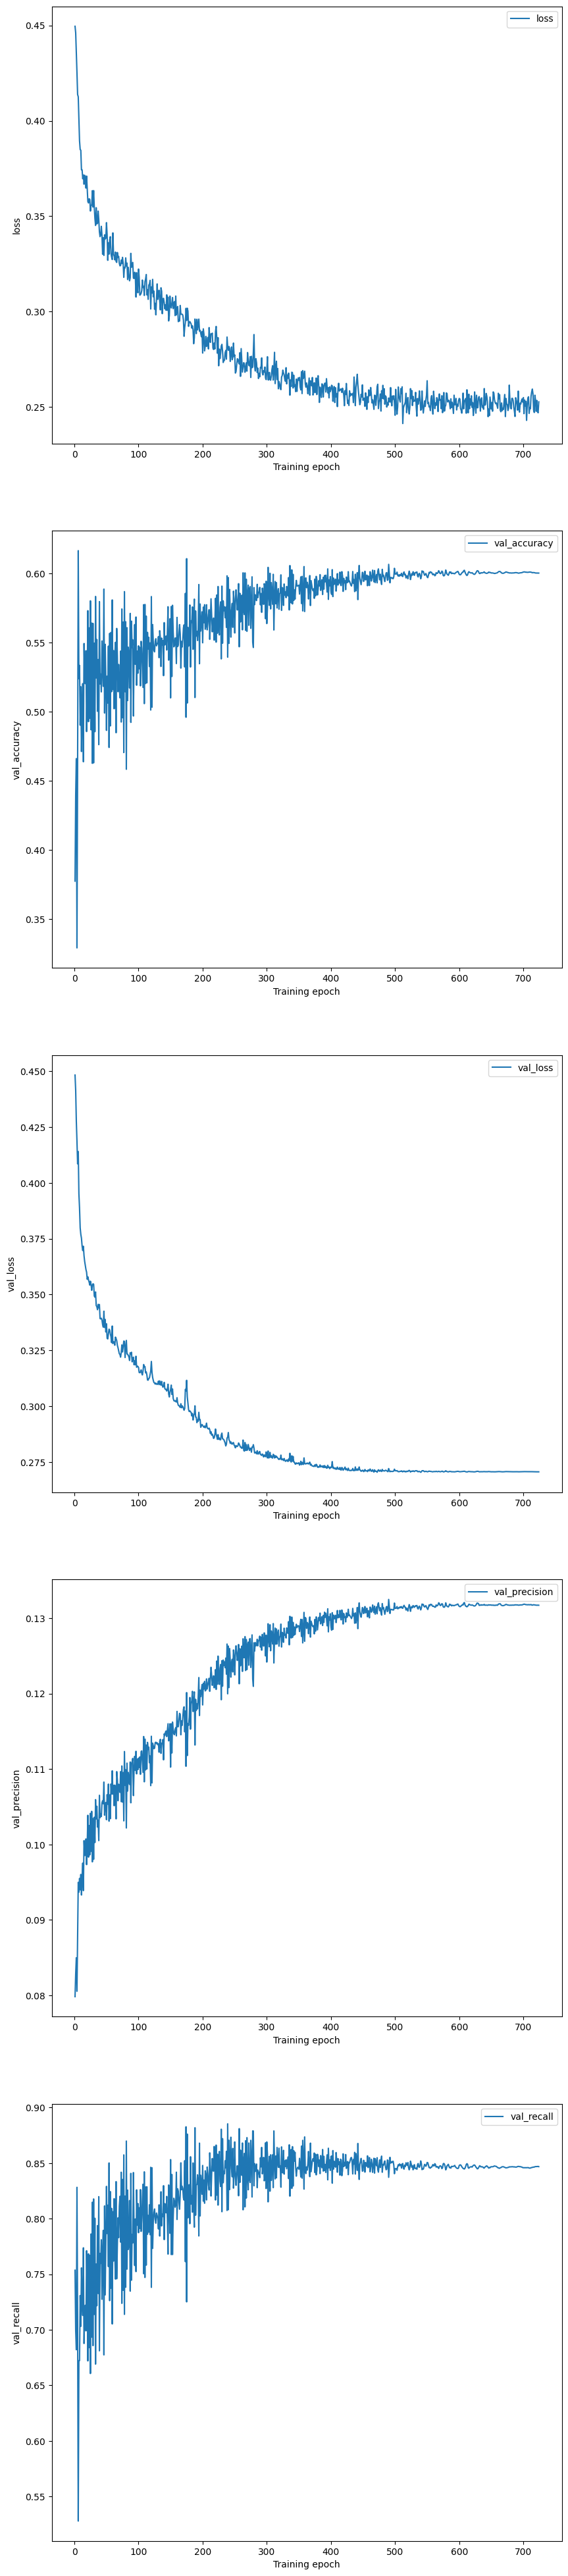

In [15]:
plot_stats(stats)

In [16]:
def plot_model_stats(figsize=(10, 50), model_name=""):
    stats = load_model_stats(model_name)
    plot_stats(stats, figsize=figsize, name=model_name)

In [17]:
def plot_all_model_stats(sample_stats, figsize=(10, 50)):
    stats_names = list(sample_stats.keys())
    f, ax = plt.subplots(len(stats_names), 1, figsize=figsize)
    for model_name in MODEL_SHORTHANDS:
        try:
            stats = load_model_stats(model_name)
            if len(stats_names)==1:
                ax = np.array([ax])
            for key, axx in zip(stats_names, ax.reshape(-1,)):
                axx.plot(
                    range(1, len(stats[key]) + 1),
                    stats[key],
                    label=model_name)
                axx.set_xlabel("Training epoch")
                axx.set_ylabel(key)
                axx.legend()
        except FileNotFoundError as e:
            pass

/home/albert_kwok/ProgrammingWork/GeometricDeepLearning/3dsg_reader/notebooks/../outputs/stats/QueryInGat(e_enc="all_minilm_l6v2",n_enc="all_minilm_l6v2",q_enc="all_minilm_l6v2",multi=true,hidden_dims=[64,64,64],out_dim=1,heads=4)/569.h5
/home/albert_kwok/ProgrammingWork/GeometricDeepLearning/3dsg_reader/notebooks/../outputs/stats/QueryMpn(e_enc="all_minilm_l6v2",n_enc="all_minilm_l6v2",q_enc="all_minilm_l6v2",multi=true,hidden_dims=[128,128,128],out_dim=1)/614.h5
/home/albert_kwok/ProgrammingWork/GeometricDeepLearning/3dsg_reader/notebooks/../outputs/stats/VirtualNodeWrapper(e_enc="all_minilm_l6v2",n_enc="all_minilm_l6v2",q_enc="all_minilm_l6v2",multi=true,model="Gat(hidden_dims=[64,64,64],out_dim=1,heads=4)",query_mlp=false)/724.h5
/home/albert_kwok/ProgrammingWork/GeometricDeepLearning/3dsg_reader/notebooks/../outputs/stats/VirtualNodeWrapper(e_enc="all_minilm_l6v2",n_enc="all_minilm_l6v2",q_enc="all_minilm_l6v2",multi=true,model="Gat(hidden_dims=[128,128,128],out_dim=1,heads=4)",qu

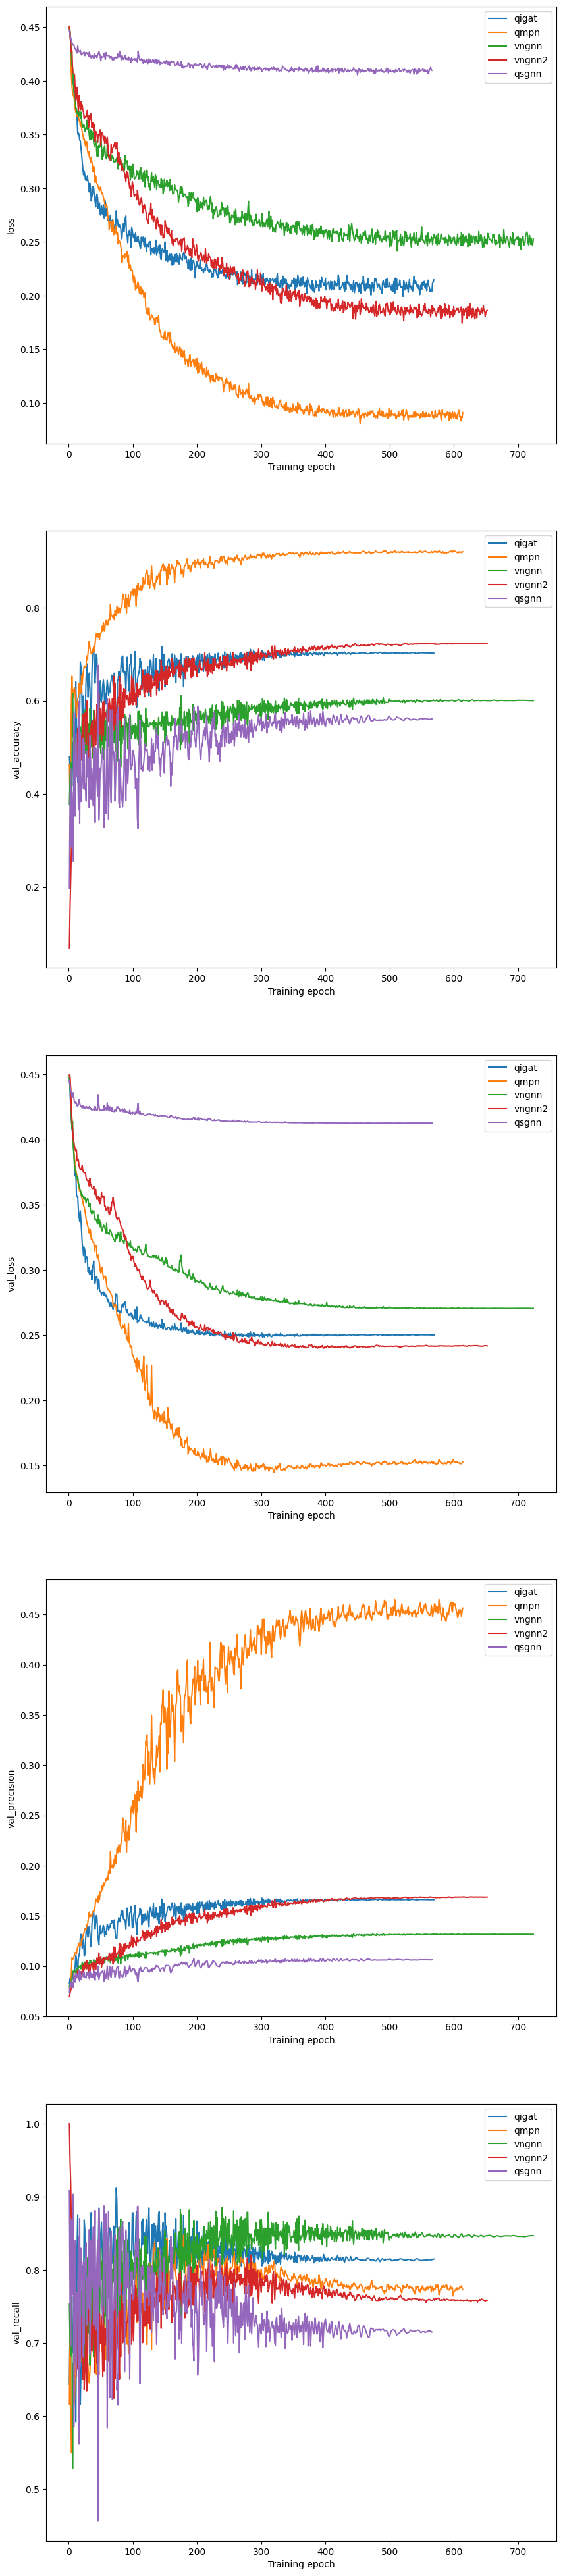

In [18]:
plot_all_model_stats(stats)